## Xenium Single-Cell Spatial Analysis with Squidpy

This notebook explores 10x Genomics Xenium spatial transcriptomics data using Squidpy. Unlike Visium, which captures gene expression from relatively large spots (~55 µm) that may contain multiple cells, Xenium provides true single-cell resolution by assigning transcripts directly to segmented individual cells.

The dataset is accessed through the SpatialData framework, a standard approach for working with Xenium outputs and other spatial omics data.

### Analysis Pipeline

1. Import Xenium data using spatialdata-io  
2. Perform quality control, including evaluation of control probes and decoding error rates  
3. Apply normalization, identify highly variable genes (HVGs), and perform dimensionality reduction (PCA, UMAP), followed by Leiden clustering  
4. Construct a spatial neighbor graph using Delaunay triangulation  
5. Compute centrality measures  
6. Conduct co-occurrence analysis  
7. Assess spatial autocorrelation using Moran’s I  
8. Visualize spatial gene expression patterns  

In [1]:
!pip install scanpy squidpy igraph leidenalg scikit-image dask spatialdata spatialdata-io spatialdata-plot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of s3fs to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Lung_2fov/Xenium_V1_human_Lung_2fov_outs.zip
!unzip Xenium_V1_human_Lung_2fov_outs.zip -d Xenium

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  265M  100  265M    0     0  55.6M      0  0:00:04  0:00:04 --:--:-- 58.3M
Archive:  Xenium_V1_human_Lung_2fov_outs.zip
  inflating: Xenium/analysis_summary.html  
 extracting: Xenium/analysis.zarr.zip  
  inflating: Xenium/cell_boundaries.csv.gz  
  inflating: Xenium/cell_boundaries.parquet  
  inflating: Xenium/cell_feature_matrix.h5  
 extracting: Xenium/cell_feature_matrix.zarr.zip  
  inflating: Xenium/cells.csv.gz     
  inflating: Xenium/cells.parquet    
 extracting: Xenium/cells.zarr.zip   
  inflating: Xenium/experiment.xenium  
  inflating: Xenium/metrics_summary.csv  
   creating: Xenium/morphology_focus/
  inflating: Xenium/morphology_focus/morphology_focus_0000.ome.tif  
  inflating: Xenium/morphology.ome.tif  
  inflating: Xenium/nucleus_boundaries.csv.gz  
  inflating: Xenium/nucleus_boundaries.parquet  
  infl

In [4]:
import spatialdata as sd
import spatialdata_plot
from spatialdata_io import xenium
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

xenium_path = "./Xenium"

sdata = xenium(xenium_path, cells_as_circles=True)
adata = sdata["table"]
print(adata)

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


WARNING  The `feature_key` column feature_name is categorical with unknown categories. Please ensure the categories
         are known before calling `PointsModel.parse()` to avoid significant performance implications due to the   
         need for dask to compute the categories. If you did not use PointsModel.parse() explicitly in your code   
         (e.g. this message is coming from a reader in `spatialdata_io`), please report this finding.              
AnnData object with n_obs × n_vars = 11898 × 289
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


In [5]:
sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

cprobes = adata.obs["control_probe_counts"].sum() / adata.obs["total_counts"].sum() * 100
cwords  = adata.obs["control_codeword_counts"].sum() / adata.obs["total_counts"].sum() * 100
print(f"Negative DNA probe %: {cprobes:.2f}")
print(f"Negative decoding %:  {cwords:.2f}")

Negative DNA probe %: 0.00
Negative decoding %:  0.01


In [6]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, flavor="igraph", directed=False, n_iterations=2)

/tmp/ipykernel_2426/1200217703.py:1: UserWarning: Some cells have zero counts
  sc.pp.normalize_total(adata)


In [7]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


ERROR: Unable to fetch palette, reason: 'leiden_colors'. Using `None`.


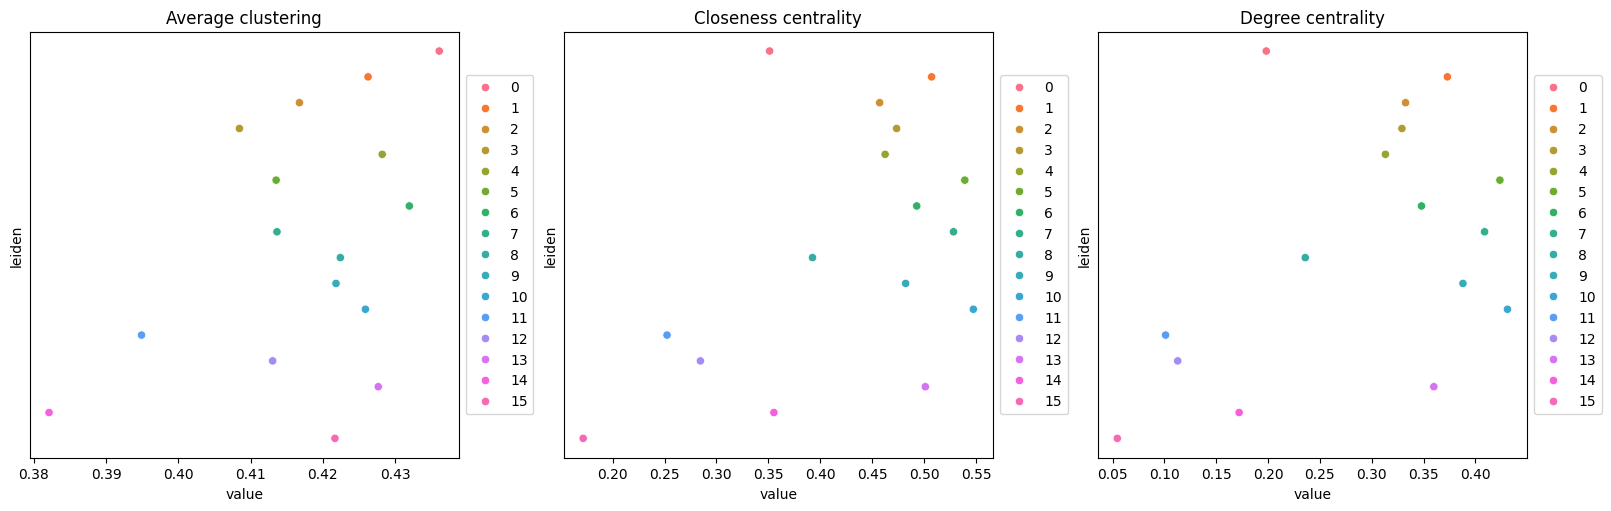

In [8]:
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(16, 5))

ERROR: Unable to fetch palette, reason: 'leiden_colors'. Using `None`.


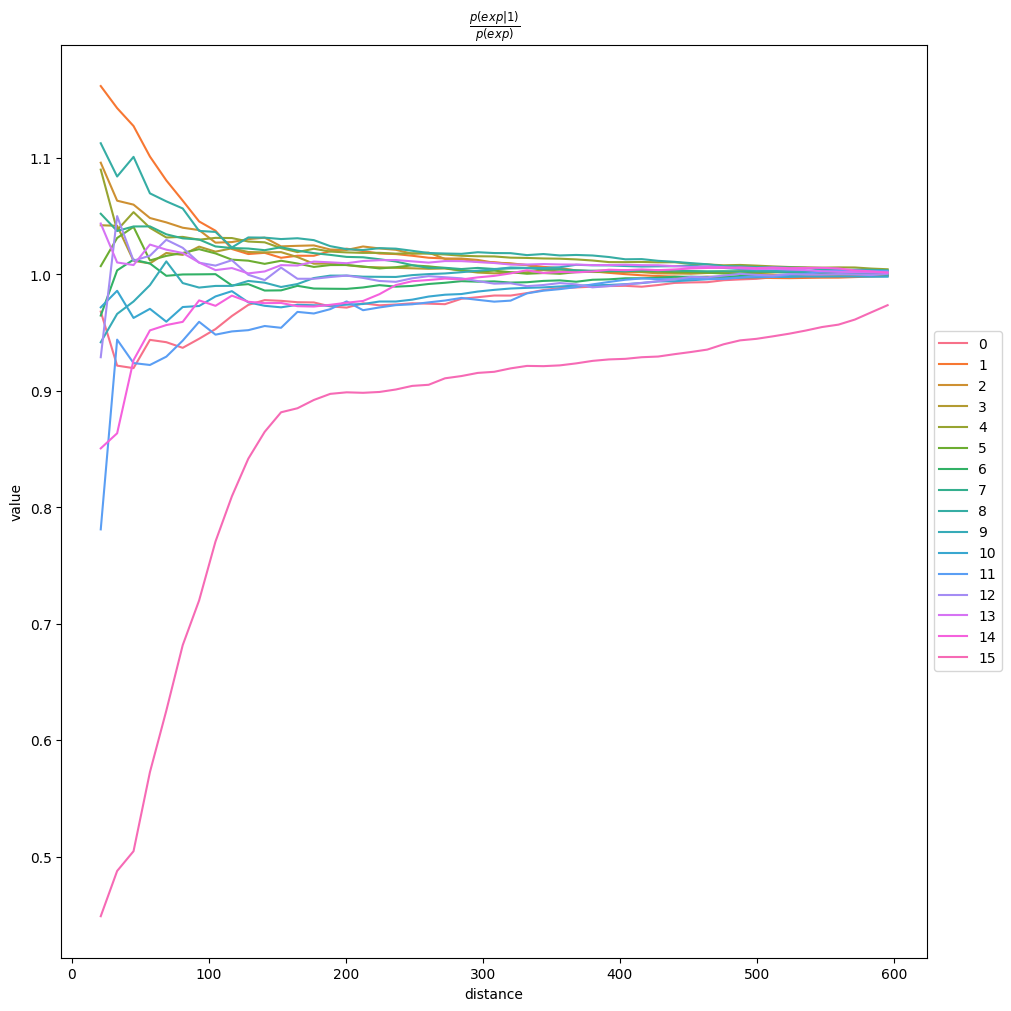

In [9]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)
sq.gr.co_occurrence(adata_subsample, cluster_key="leiden")
sq.pl.co_occurrence(adata_subsample, cluster_key="leiden", clusters="1", figsize=(10, 10))

In [10]:
sq.gr.spatial_autocorr(adata, mode="moran")

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


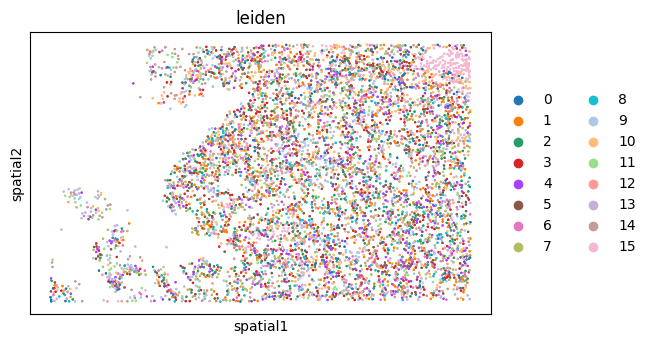

In [11]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)

sq.pl.spatial_scatter(
    adata_subsample,
    color=["leiden"],
    shape=None,
    size=2,
    img=False,
)